Dataset shape: (1479, 8)


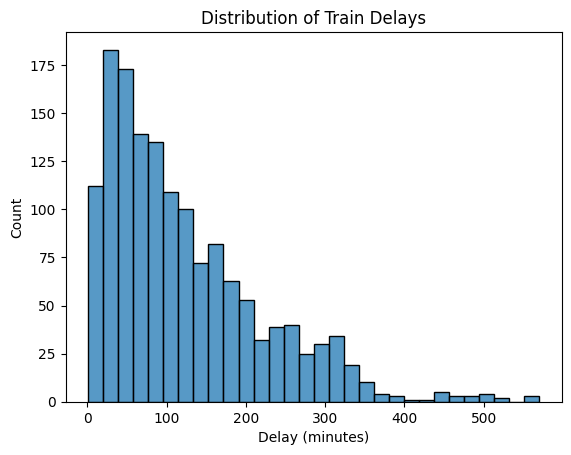

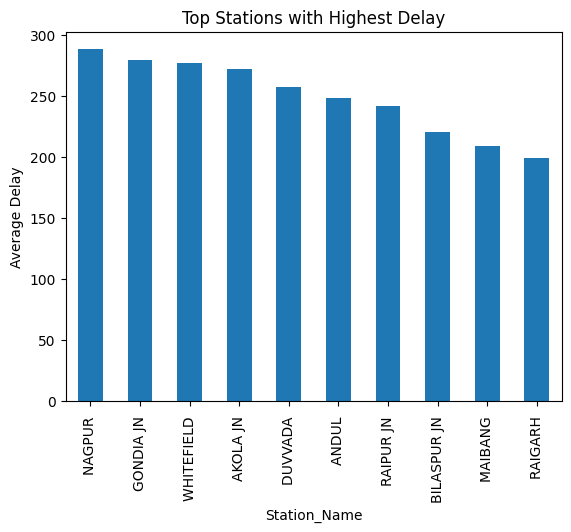

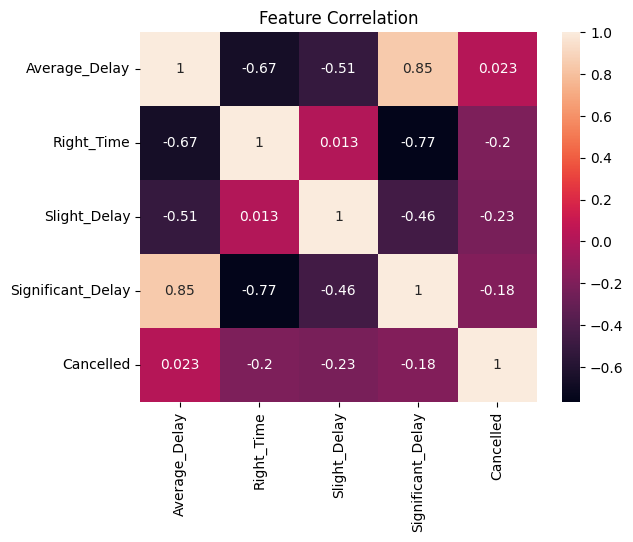

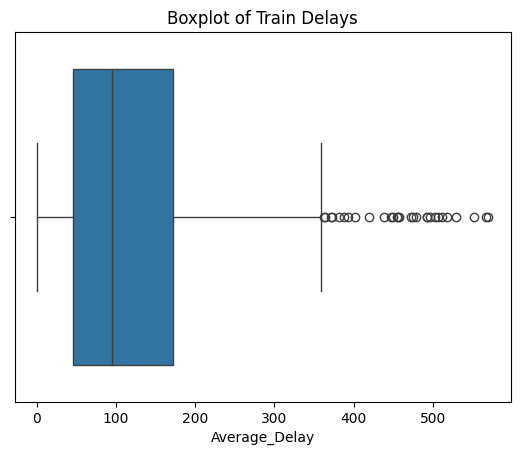

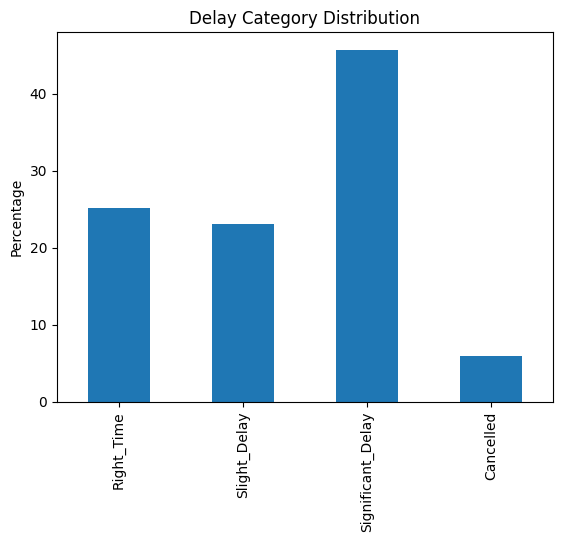

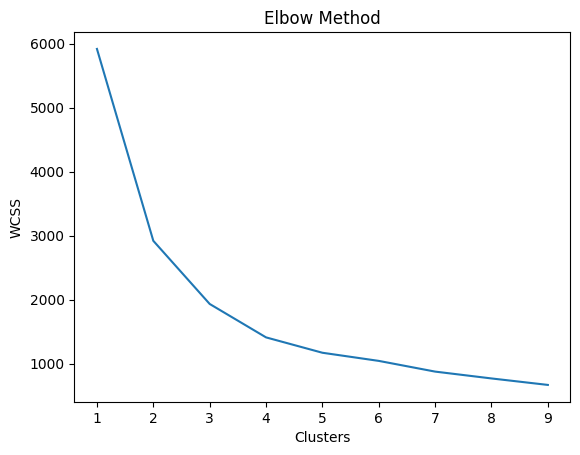

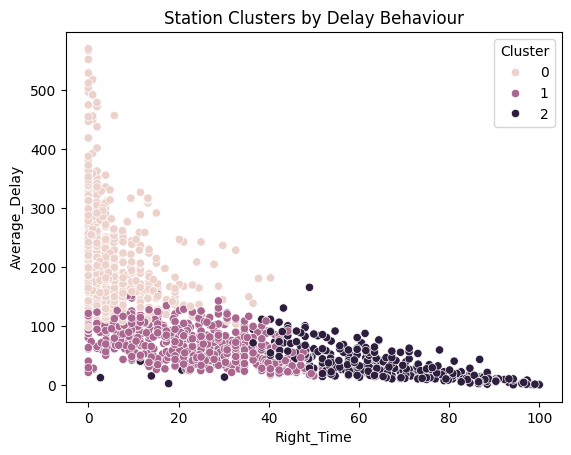

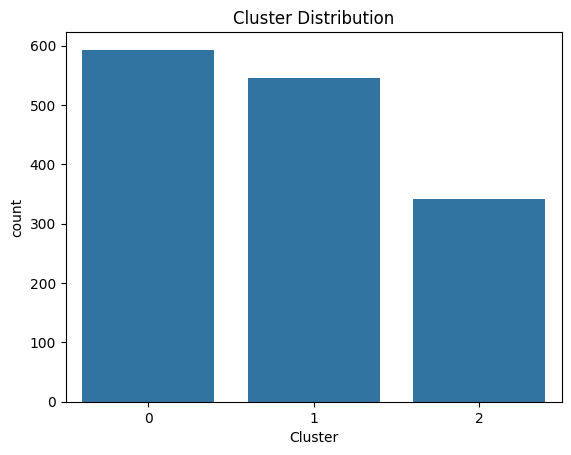

MAE: 20.470331911378786
R2 Score: 0.8651686083646827


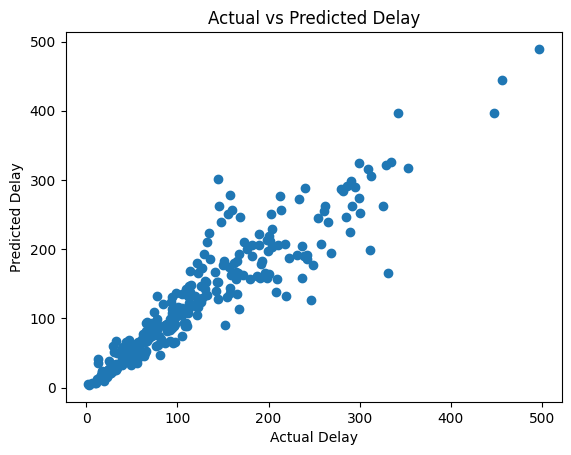

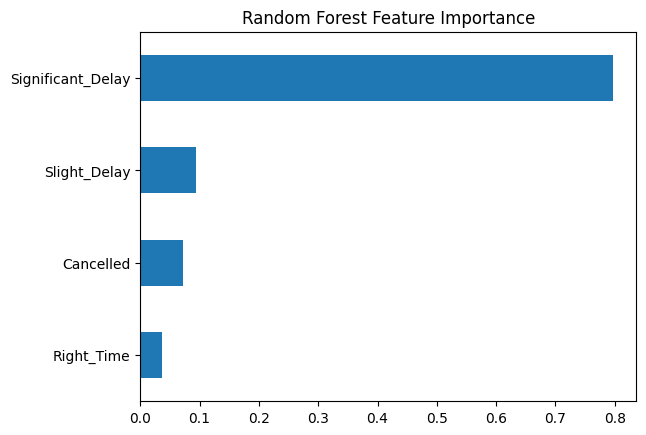

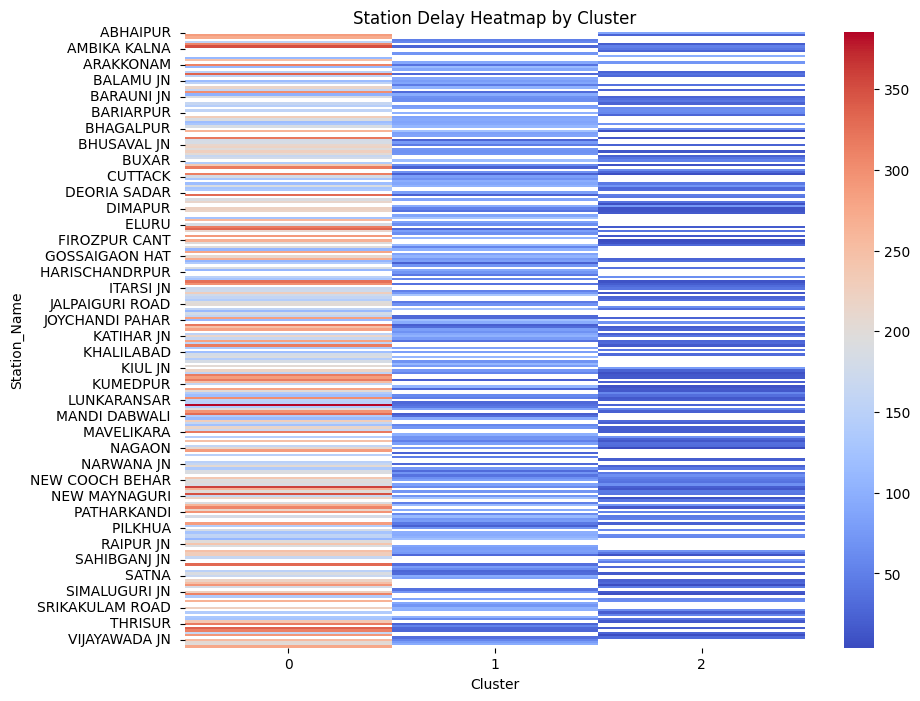

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#---------------------------------------------------

# 2. Load dataset (Upload Dataset folder from GitHub)

#---------------------------------------------------

# Corrected path to find CSV files directly in /content/
files = glob.glob("/content/*.csv")

df_list = []

for f in files:
    # Exclude Train_List.csv and sample_data csvs if they exist in /content/
    if "Train_List.csv" not in f and "sample_data" not in f:
        temp = pd.read_csv(f)
        temp["Train"] = f.split("/")[-1].replace(".csv","")
        df_list.append(temp)

# Check if df_list is empty before concatenating
if not df_list:
    raise ValueError("No suitable CSV files found to concatenate. Please ensure your train route CSVs are in /content/.")

df = pd.concat(df_list, ignore_index=True)

# Clean column names

df.columns = df.columns.str.replace(" ","_")
df.columns = df.columns.str.replace("(","", regex=False)
df.columns = df.columns.str.replace(")","", regex=False)

df = df.rename(columns={
"Average_Delaymin":"Average_Delay",
"Right_Time_0-15_min's":"Right_Time",
"Slight_Delay_15-60_min's":"Slight_Delay",
"Significant_Delay_>1_Hour":"Significant_Delay",
"Cancelled/Unknown":"Cancelled"
})

df = df.fillna(0)

print("Dataset shape:",df.shape)
df.head()

#---------------------------------------------------

# 3. Exploratory Data Analysis (Key Visualizations)

#---------------------------------------------------

# Delay distribution

plt.figure()
sns.histplot(df["Average_Delay"], bins=30)
plt.title("Distribution of Train Delays")
plt.xlabel("Delay (minutes)")
plt.show()

# Top delayed stations

top = df.groupby("Station_Name")["Average_Delay"].mean().sort_values(ascending=False).head(10)

plt.figure()
top.plot(kind="bar")
plt.title("Top Stations with Highest Delay")
plt.ylabel("Average Delay")
plt.show()

# Correlation heatmap

plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

# Boxplot of delays

plt.figure()
sns.boxplot(x=df["Average_Delay"])
plt.title("Boxplot of Train Delays")
plt.show()

# Delay category distribution

delay_cols = ["Right_Time","Slight_Delay","Significant_Delay","Cancelled"]

plt.figure()
df[delay_cols].mean().plot(kind="bar")
plt.title("Delay Category Distribution")
plt.ylabel("Percentage")
plt.show()

#---------------------------------------------------

# 4. K-Means Clustering

#---------------------------------------------------

features = df[["Average_Delay","Right_Time","Slight_Delay","Significant_Delay"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method

wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Train final model

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster visualization

plt.figure()
sns.scatterplot(x=df["Right_Time"], y=df["Average_Delay"], hue=df["Cluster"])
plt.title("Station Clusters by Delay Behaviour")
plt.show()

# Cluster distribution

plt.figure()
sns.countplot(x=df["Cluster"])
plt.title("Cluster Distribution")
plt.show()

#---------------------------------------------------

# 5. Random Forest Delay Prediction

#---------------------------------------------------

X = df[["Right_Time","Slight_Delay","Significant_Delay","Cancelled"]]
y = df["Average_Delay"]

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test,pred)}")
print(f"R2 Score: {r2_score(y_test,pred)}")

#---------------------------------------------------

# 6. Model Evaluation Visualizations
# Actual vs predicted

plt.figure()
plt.scatter(y_test,pred)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted Delay")
plt.show()

# Feature importance

importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

# Heatmap of station delay by cluster

pivot = df.pivot_table(values="Average_Delay",
index="Station_Name",
columns="Cluster",
aggfunc="mean")

plt.figure(figsize=(10,8))
sns.heatmap(pivot,cmap="coolwarm")
plt.title("Station Delay Heatmap by Cluster")
plt.show()

In [ ]:
print("Contents of /content/:")
!ls -F /content/

print("\nContents of /content/Dataset/ (if it exists):")
!ls -F /content/Dataset/

print("\nContents of /content/Dataset/Train_Route/ (if it exists):")
!ls -F /content/Dataset/Train_Route/*.csv


Contents of /content/:
02501.csv  12424.csv  12516.csv  14620.csv  15946.csv  22502.csv
02502.csv  12503.csv  12519.csv  15629.csv  15960.csv  22512.csv
02517.csv  12504.csv  12520.csv  15630.csv  20501.csv  sample_data/
02518.csv  12507.csv  13181.csv  15647.csv  20503.csv  Train_List.csv
05639.csv  12508.csv  13182.csv  15648.csv  20504.csv
05640.csv  12509.csv  14037.csv  15909.csv  22449.csv
12346.csv  12510.csv  14038.csv  15910.csv  22450.csv
12423.csv  12515.csv  14619.csv  15945.csv  22501.csv

Contents of /content/Dataset/ (if it exists):
ls: cannot access '/content/Dataset/': No such file or directory

Contents of /content/Dataset/Train_Route/ (if it exists):
ls: cannot access '/content/Dataset/Train_Route/*.csv': No such file or directory
